In [2]:
#Unpickling the data
import pickle

with open(r"C:\Users\patra\OneDrive\Desktop\FACE DETECTION\DATA\images.p","rb") as f:
  images = pickle.load(f)
with open(r"C:\Users\patra\OneDrive\Desktop\FACE DETECTION\DATA\labels.p","rb") as f:
  labels = pickle.load(f)

In [3]:
print(images.shape)
print(labels.shape)

(298, 100, 100)
(298,)


In [4]:
set(labels)

{'Sapna', 'Simran', 'dibya'}

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

labels = le.fit_transform(labels)

In [6]:
set(labels)

{0, 1, 2}

In [7]:
le.inverse_transform([0,1,2])

array(['Sapna', 'Simran', 'dibya'], dtype='<U6')

In [8]:
p = len(set(labels))
print("Total number of Persons : ",p)

Total number of Persons :  3


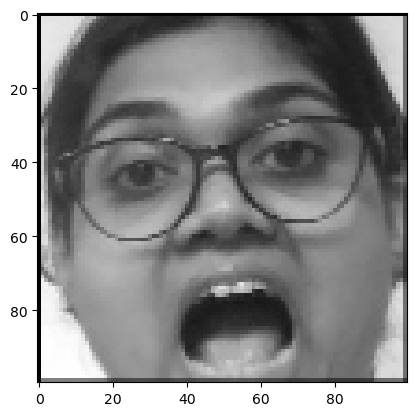

In [9]:
import matplotlib.pyplot as plt
plt.imshow(images[15],cmap='gray')
plt.show()

In [10]:
import cv2

In [11]:
def preprocessing(img):
  img = cv2.equalizeHist(img)#It is used to improve the contrast/brightness distribution of a grayscale image.
  img = img.reshape(100,100,1) 
  img = img/255
  return img

In [12]:
import numpy as np

In [13]:
images = np.array(list(map(preprocessing,images)))
print("Shape of Input : ",images.shape)

Shape of Input :  (298, 100, 100, 1)


In [14]:
from keras.utils import to_categorical
labels = to_categorical(labels)

In [15]:
labels

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0

In [16]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

from keras.layers import Conv2D, MaxPooling2D, Flatten

In [17]:
#Model Training
def Lenet_Model():
  model = Sequential()
  #Convolutional and ReLU Layer
  model.add(Conv2D(30,(5,5),input_shape=(100,100,1),activation='relu'))
#30:Each filter tries to learn a different pattern from the image
    
  #MaxPooling Layer
  model.add(MaxPooling2D(pool_size=(2,2)))

  #Convolutional and ReLU Layer
  model.add(Conv2D(15,(3,3),activation='relu'))
  #MaxPooling Layer
  model.add(MaxPooling2D(pool_size=(2,2)))

  #Flatten Layer/Input Layer
  model.add(Flatten())

  #Hidden Layers
  model.add(Dense(50,activation='relu'))

  #Output Layer
  model.add(Dense(p,activation='softmax'))
  model.compile(Adam(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'])
  return model

In [18]:
model = Lenet_Model()
model.summary()

C:\Users\patra\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 96, 96, 30)          │             780 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 30)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 46, 46, 15)          │           4,065 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 15)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 7935)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │         396,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             153 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 401,798 (1.53 MB)

 Trainable params: 401,798 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
h = model.fit(images,labels,validation_split=0.1,epochs=10)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.4963 - loss: 3.2823 - val_accuracy: 0.0000e+00 - val_loss: 2.3925
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9142 - loss: 0.2189 - val_accuracy: 1.0000 - val_loss: 4.7922e-06
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9963 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 1.1327e-04
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.9963 - loss: 0.0174 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.9963 - loss: 0.0670 - val_accuracy: 1.0000 - val_loss: 5.1657e-08
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.9963 - loss: 0.0229 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9963 - loss: 0.0272 - val_accuracy: 1.0000 - val_loss: 8.3446e-08
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.9925 - loss: 0.0311 - val_a

In [20]:
model.save('final_model.h5')

In [25]:
import os
import cv2
import numpy as np

labels = ["Sapna", "Simran", "dibiya"]

for filename in os.listdir("IMAGES"):

    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    image = cv2.imread(os.path.join("IMAGES", filename))

    if image is None:
        continue

    # Actual name from filename
    actual_name = filename.rsplit("_", 1)[0]

    # Resize
    image = cv2.resize(image, (100, 100))

    # Convert to grayscale
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Same preprocessing as training
    image = cv2.equalizeHist(image)

    # Normalize
    image = image / 255.0

    # IMPORTANT: add batch dimension
    processed = image.reshape(1, 100, 100, 1)

    # Prediction
    prediction = model.predict(
        processed,
        verbose=0
    )[0]

    predicted_class = np.argmax(prediction)

    predicted_name = labels[predicted_class]

    confidence = prediction[predicted_class] * 100

    print(
        f"Actual: {actual_name:10} | "
        f"Predicted: {predicted_name:10} | "
        f"Confidence: {confidence:.2f}%"
    )

Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Predicted: dibiya     | Confidence: 100.00%
Actual: dibya      | Pred